# **Large-scale structure final notebook**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

import astropy.units as u
from astropy.cosmology import LambdaCDM
import scipy.stats as sps

cosmo = LambdaCDM(H0 = 70, Ode0=0.7, Om0=0.3)

from config.settings import DATA_DIR, FIG_DIR

from config.plotting import Tab10, Tab20

## 1. Load and prepare data

In [2]:
# bins = [[0.01, 0.04], [0.04, 0.08], [0.08, 0.12], [0.12, 0.16], [0.16, 0.20], [0.20, 0.40]]
# bin_names = ["001-004", "004-008", "008-012", "012-016", "016-020", "020-040"]

zbins = [[0.01, 0.04], [0.04, 0.07], [0.07, 0.10], [0.10, 0.14], [0.14, 0.18], [0.18, 0.40]]
zbin_names = ["001-004", "004-007", "007-010", "010-014", "014-018", "018-040"]
bins_d = cosmo.comoving_distance(np.array(zbins)).to_value(u.Mpc)

surveys = ["2mass", "6df", "sdss"]

### 1.1. Load data maps and random maps

In [3]:
data = []

for i in range(len(surveys)):
    excess_s = []
    for j in range(len(zbin_names)):
        name_ij = f"{DATA_DIR/surveys[i]}/{surveys[i]}_{zbin_names[j]}"
        excess_s.append(np.load(f"{name_ij}_data.npy"))
    data.append(excess_s)

### 1.2. Masks

In [4]:
masks = []

for i in range(len(surveys)):
    masks.append(np.load(f"{DATA_DIR/surveys[i]}/{surveys[i]}_mask.npy"))

In [5]:
from astropy.coordinates import SkyCoord

MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg').galactic
theta_MW, phi_MW = np.pi/2 - MW_plane.b.rad, MW_plane.l.rad

EQ_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg').galactic
theta_EQ, phi_EQ = np.pi/2 - EQ_plane.b.rad, EQ_plane.l.rad

SG_plane = SkyCoord(sgl=np.linspace(0, 360, 100), sgb=0, frame='supergalactic', unit='deg').galactic
theta_SG, phi_SG = np.pi/2 - SG_plane.b.rad, SG_plane.l.rad

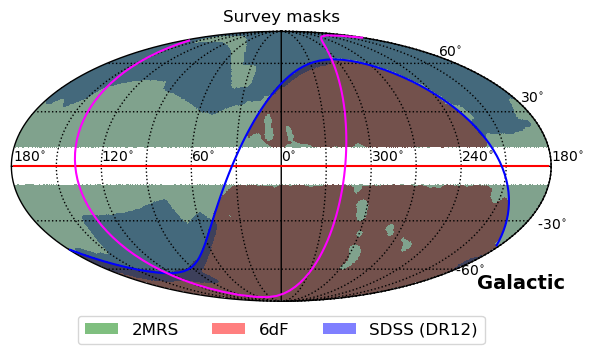

In [6]:
from matplotlib.patches import Patch

cmaps = ["Greens", "Reds", "Blues"]
colors = ["green", "red","blue"]
names = ["2MRS", "6dF", "SDSS (DR12)"]

plt.figure(figsize=(7, 4))
ax = plt.subplot(111)
plt.sca(ax)

legend_elements = []

for i in range(len(surveys)):
    legend_elements.append(Patch(facecolor=colors[i], alpha=0.5, label=names[i]))
    if i == 0:
        hp.mollview(masks[i],alpha=0.5*masks[i], cmap=cmaps[i], cbar=False, coord=['C', 'G'], xsize=900, hold=True,
                    title="Survey masks")
    else:
        hp.mollview(masks[i], reuse_axes=True, alpha=0.5 * masks[i], cmap=cmaps[i], cbar=False, xsize=900, title="Survey masks",
                    coord='C', notext=True)
        
hp.graticule()

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='G')
hp.projplot(theta_SG, phi_SG, color='magenta', coord='G')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

plt.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.1), ncol=3, loc='center', fontsize=12)
plt.savefig(f"{FIG_DIR}/lss-masks.png", bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

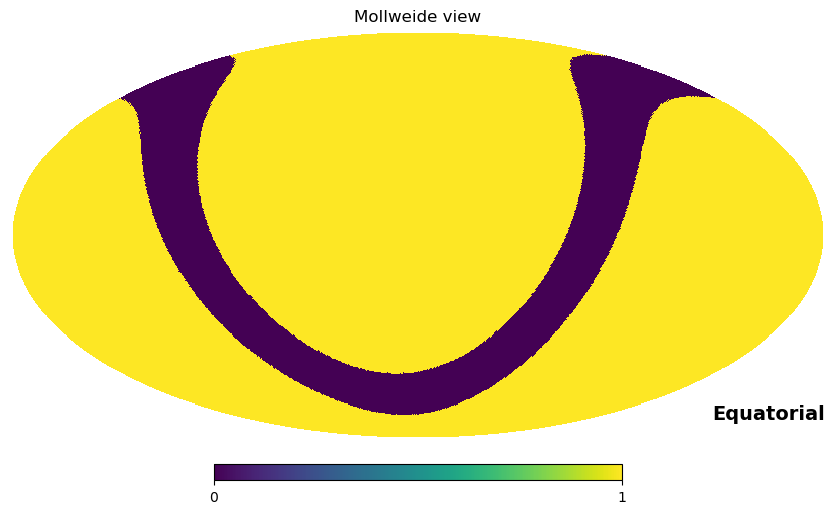

In [7]:
mask_total = (np.sum(masks, axis=0) > 0)
hp.mollview(mask_total, coord='C', rot=(180, 0, 0))

## 2. Look (meticulously) at data

Here we notice that the data does not follow the standard Poisson distribution, but reveals **overdispersion** and is aligned with *negative binomial distribition (NB)*

sdss
Fitted Parameters:
 n (size) = 0.507
 p (prob) = 0.535


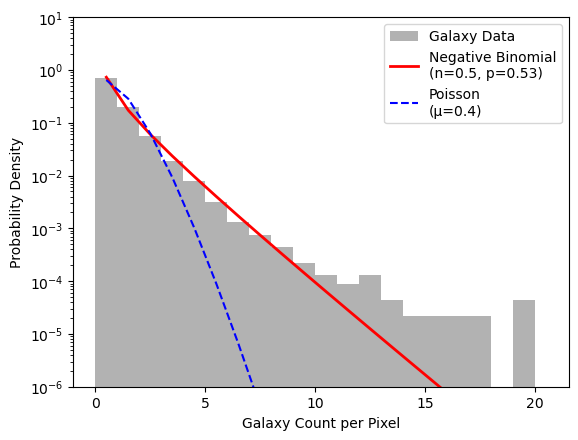

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

j = 2
i = 2
print(surveys[i])
counts = data[i][j][masks[i]]

# 1. Calculate the real data mean and variance
mu = np.mean(counts)
var = np.var(counts)

# Quick sanity check: for clustering, variance MUST be greater than the mean
if var <= mu:
    print("Warning: Data is not overdispersed. Negative Binomial might not fit.")

# 2. Calculate nbinom parameters (Method of Moments)
p_param = mu / var
n_param = (mu**2) / (var - mu)

print(f"Fitted Parameters:\n n (size) = {n_param:.3f}\n p (prob) = {p_param:.3f}")

# 3. Generate the fit for plotting
x = np.arange(0, np.max(counts) + 1)
# scipy.stats.nbinom takes (n, p)
pmf_nb = sps.nbinom.pmf(x, n_param, p_param) 

# 4. Optional: Compare to a Poisson distribution with the same mean
pmf_poisson = sps.poisson.pmf(x, mu)

# Plotting the comparison
plt.hist(counts, bins=x, density=True, alpha=0.6, label='Galaxy Data', color='gray')
plt.plot(x+0.5, pmf_nb, 'r-', lw=2, label=f'Negative Binomial\n(n={n_param:.1f}, p={p_param:.2f})')
plt.plot(x+0.5, pmf_poisson, 'b--', lw=1.5, label=f'Poisson\n(μ={mu:.1f})')
plt.xlabel('Galaxy Count per Pixel')
plt.ylabel('Probability Density')

plt.yscale('log')
plt.ylim(1e-6, 10)
plt.legend()
plt.show()

## 3. Overdensity calculation

Pixel size in healpix maps is defined as 
$$ \theta_\mathrm{pix} = \sqrt{\dfrac{4\pi}{n_\mathrm{pix}}} = \dfrac{1}{n_\mathrm{side}}\sqrt{\dfrac{\pi}{3}}  $$

Hence, given $\theta_\mathrm{pix}$, we get required $n_\mathrm{side}$ as
$$n_\mathrm{side} = \dfrac{1}{\theta_\mathrm{pix}}\sqrt{\dfrac{\pi}{3}}$$

In [9]:
nside = 128
theta_pix_rad = 1 / nside * np.sqrt(np.pi/3)
theta_pix_deg = np.rad2deg(theta_pix_rad)
print(theta_pix_deg, np.rad2deg(hp.nside2resol(nside)))
print(1/theta_pix_rad * np.sqrt(np.pi/3))

0.45806485490898746 0.45806485490898746
128.0


In [10]:
# let us look at bin j as the between [0..4]
j = 3

import astropy.units as u
z_avg = (zbins[j][0] + zbins[j][1])/2

pix_size = np.rad2deg(hp.nside2resol(nside))  # ~0.5 degree resolution
sm_deg = np.max(((5 * u.Mpc / cosmo.kpc_comoving_per_arcmin(z_avg)).to_value(u.deg), pix_size))

decorrelation_scale = 3 * sm_deg
decorrelation_hp_approx_size = 1 / np.deg2rad(decorrelation_scale) * np.sqrt(np.pi/3)
# now we want to make it a power of 2
decorrelation_hp_side = 2**round(np.log2(decorrelation_hp_approx_size))
decorrelation_hp_npix = hp.nside2npix(decorrelation_hp_side)
print(decorrelation_hp_side)

theta_decorr, phi_decorr = hp.pix2ang(decorrelation_hp_side, np.arange(decorrelation_hp_npix))
subsampled_pix = hp.ang2pix(nside, theta_decorr, phi_decorr)

32


In [11]:
# smoothing
excess_s = []
avgs = []
ovds = []

for i in range(len(surveys)):
    # AVERAGE VALUE in the masked region
    avg_ij = np.average(data[i][j][masks[i]])  
    avgs.append(avg_ij) 
    
    # SMOOTHED DATA excess values to simplify the distribution correction procedure
    excess_ij = hp.smoothing(                     
        (data[i][j] - avg_ij) * masks[i],       # data in the masked region is corrected by the average value
        sigma=np.deg2rad(sm_deg)
        ) * masks[i]                            # only data in the masked region is non-zero
    
    # GIBBS PHENOMENON !!!
    # MORE NEGATIVE VALUES THAN BEFORE SMOOTHING DUE TO MASKING EFFECTS
    print(f"{surveys[i]} == BEFORE SMOOTHING: {np.min((data[i][j] - avg_ij) * masks[i]):.4f}, AVG {avg_ij:.4f}")
    print(f"{surveys[i]} == AFTER SMOOTHING: {np.min(excess_ij * masks[i]):.4f}, AVG {np.average(excess_ij):.4g}")
        
    new_avg_ij = avg_ij + np.average(excess_ij)  # new average
    excess_ij = np.maximum(excess_ij, -0.999 * new_avg_ij)   # by construction excess cannot be more than average
    excess_s.append(excess_ij)
    
    # OVERDENSITY RECALCULATED WITH A NEW MEAN: excess / avg = (data - avg) / avg
    ovd_ij = excess_ij / new_avg_ij
    empirical_mean = np.average(ovd_ij[masks[i]]) + 1                   
    ovds.append(((ovd_ij + 1)/empirical_mean - 1) * masks[i])
    
ovds1 = np.array(ovds)

# GET READY FOR DISTRIBUTION MANIPULATUION
count_bins = np.arange(-1.2, 1.2 * np.max(ovds1), 0.1)
delta_line = np.linspace(1.2 * min(count_bins), 1.2 * max(count_bins), 10000)       

2mass == BEFORE SMOOTHING: -0.0542, AVG 0.0542
2mass == AFTER SMOOTHING: -0.0589, AVG 3.965e-05
6df == BEFORE SMOOTHING: -0.1052, AVG 0.1052
6df == AFTER SMOOTHING: -0.1070, AVG 0.0003089
sdss == BEFORE SMOOTHING: -0.6704, AVG 0.6704
sdss == AFTER SMOOTHING: -0.6688, AVG 0.001284


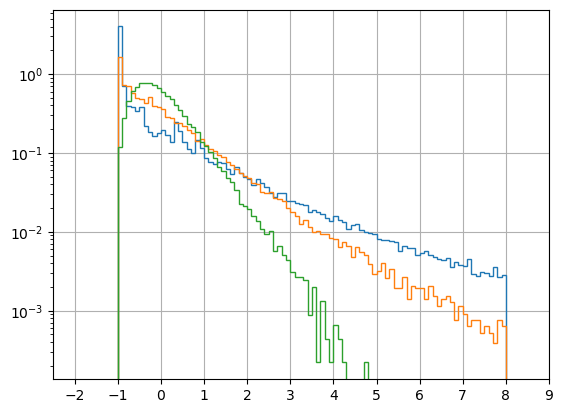

In [12]:
for i in range(len(surveys)):
    b = plt.hist(ovds[i][masks[i]], bins=100, range=[-2.0, 8.0], histtype='step', color=Tab10[i], density=True)
plt.yscale('log')

plt.xticks(np.arange(-2, 10, 1))
plt.grid()
plt.show()

Take a random variable $X,~f_X(x)$ and transform it with a strictily monotonous (and thus invertible) function $g$, s.t. $Y = g(X)$

Then $F_Y(y) = P(Y \leqslant y) = P(X \leqslant g^{-1}(y)) = [F_X \circ g^{-1}](y)$.

This means that to get the $g$ function, we first apply $F_X^{-1}$ and then invert:

$ [F_X^{-1} \circ F_Y](y) = g^{-1}(y) $

$g(y) = [F_X^{-1} \circ F_Y]^{-1}(y) = [F_Y^{-1}\circ F_X](y)$

In [13]:
import scipy.stats as sps

2mass -- Map size: 196608 px, Mask size: 162464 px
0.319174175843657
6df -- Map size: 196608 px, Mask size: 77954 px
0.8395730399232924
sdss -- Map size: 196608 px, Mask size: 45395 px
2.4778993317038083


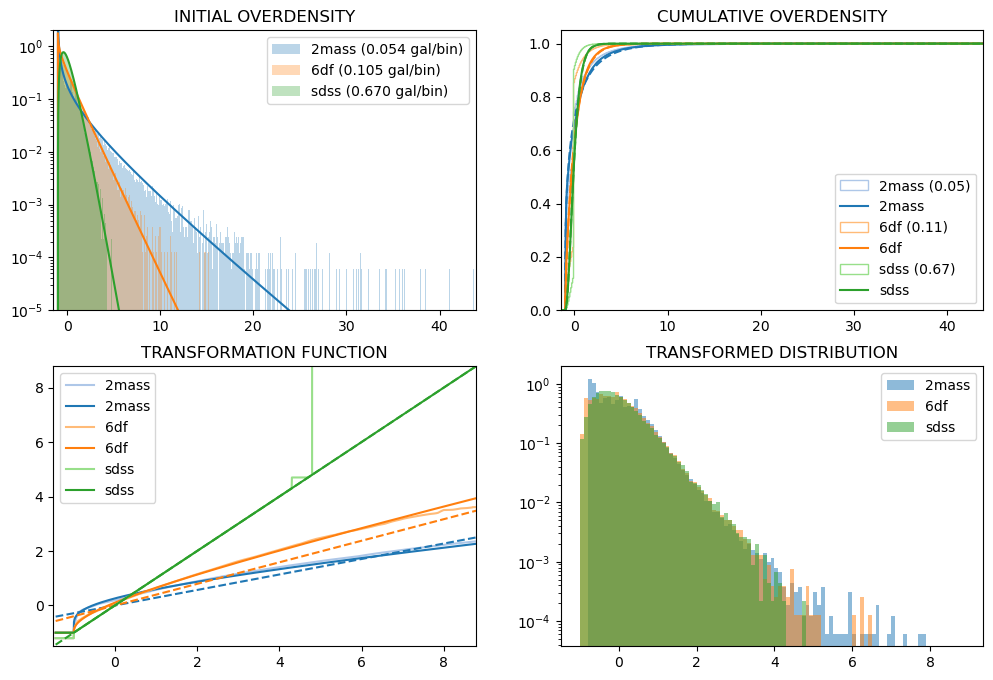

In [14]:
plt.figure(figsize=(12, 8))

# ---------------------
# ---------------------
plt.subplot(221)
plt.title("INITIAL OVERDENSITY")
distributions = []
gammas = []
dhs = []

for i in range(len(surveys)):
    excess_ij = excess_s[i]
    avg_ij = avgs[i]
    ovds_ij = ovds[i][masks[i]]  # overdensity in the masked region
    print(f"{surveys[i]} -- Map size: {excess_ij.size} px, Mask size: {np.sum(masks[i])} px")
    
    # data histogram
    dat_hist =  plt.hist(ovds_ij, bins=count_bins, density=True,
                         alpha=.3, color=Tab20[2*i],
                         label=f"{surveys[i]} ({avg_ij:.3f} gal/bin)")
    dhs.append(dat_hist[0])
        
    # distribution from histogram
    dist_i = sps.rv_histogram((dat_hist[0], dat_hist[1]), density=True)
    distributions.append(dist_i)
    
    # try gamma distribution
    # ! TAKE CORRELATION INTO ACCOUNT [NEED DECORRELATED PIXELS!]
    # CONSTRUCTED ABOVE AS SUBSAMPLED PIXELS
    # NOW NEED TO COMBINE THEM WITH THE MASK!!!
    uncorrelated = np.zeros_like(ovds[i])   # set the bool map
    uncorrelated[subsampled_pix] = True     # set the subsampled True
    uncorrelated_and_masked = np.bool_(uncorrelated * masks[i])  # True only if both uncorr. and masked
    
    alpha = 1/np.var(ovds[i][uncorrelated_and_masked])
    print(alpha)
    gm = sps.gamma(loc=-1.0, a=alpha, scale=1/alpha)
    
    gammas.append(gm)
    plt.plot(delta_line, gm.pdf(delta_line), color=Tab20[2*i])
    
plt.legend(loc=1)
plt.xlim(1.5 * np.min(ovds1), np.max((ovds1)))
plt.yscale('log')
plt.ylim(1e-5, 2.0)

# ---------------------
# ---------------------
plt.subplot(222)
plt.title("CUMULATIVE OVERDENSITY")
for i in range(len(surveys)):
    ovds_ij = ovds[i]
    avg_ij = avgs[i]
    gm = gammas[i]
    plt.hist(ovds_ij, bins=count_bins,
             density=True, cumulative=True,
             color=Tab20[2*i+1], histtype='step',
             label=f"{surveys[i]} ({avg_ij:.2f})",)
    dist_i = distributions[i]
    plt.plot(delta_line, dist_i.cdf(delta_line), color=Tab20[2*i],
             label=f"{surveys[i]}")
    plt.plot(delta_line, gm.cdf(delta_line), color=Tab20[2*i], linestyle='dashed')
    distributions.append(dist_i)

plt.legend(loc=4)
plt.xlim(1.5 * np.min(ovds1), np.max((ovds1)))

# ---------------------
# ---------------------
plt.subplot(223)
plt.title("TRANSFORMATION FUNCTION")
i_max = np.argmax(np.array(avgs))   # the richest data
avg_max = avgs[i_max]               # the density of the reachest data
gs = []
gans = []
for i in range(len(surveys)):
    avg_ij = avgs[i]
    
    # real functions
    def g(x):
        F_Ym1 = distributions[i_max].ppf
        return F_Ym1(distributions[i].cdf(x))
    gs.append(g)
    
    # analytical functions
    def g_an(x):
        F_Ym1 = gammas[i_max].ppf
        F_X = gammas[i].cdf
        return F_Ym1(F_X(x))
    
    gans.append(g_an)
    
    plt.plot(delta_line, g(delta_line),
             alpha=1.0, label=f"{surveys[i]}", color=Tab20[2*i+1])
    plt.plot(delta_line, g_an(delta_line),
             alpha=1.0, label=f"{surveys[i]}", color=Tab20[2*i], linestyle='solid')
    plt.plot(delta_line, delta_line * np.sqrt(avg_ij / avg_max), linestyle='dashed', color=Tab20[2*i])

plt.xlim(1.5 * np.min(ovds1), 0.2 * np.max((ovds1)))
plt.ylim(1.5 * np.min(ovds1), 0.2 * np.max((ovds1)))
plt.legend(loc=2)

# ---------------------
# ---------------------
ovds_new = []
plt.subplot(224)
plt.title("TRANSFORMED DISTRIBUTION")
for i in range(len(surveys)):
    ovds_ij = ovds[i]
    g = gans[i]
    ovds_new_ij = g(ovds_ij)
    # CORRECT TO MAKE OVERDENSITY AGAIN OF ZERO MEAN
    empirical_mean = np.average(ovds_new_ij[masks[i]]) + 1
    ovds_new_ij = (ovds_new_ij + 1) / empirical_mean - 1
    ovds_new.append(ovds_new_ij * masks[i])
    plt.hist(ovds_new_ij[masks[i]], alpha=0.5, bins=count_bins, label=f"{surveys[i]}", density=True)

ovds_new1 = np.array(ovds_new)

plt.xlim(-1.5, 1.2 * np.max(ovds_new1))
   
plt.yscale('log')
plt.legend()

plt.show()

0.10282219793219083


(-2.0, 4.0)

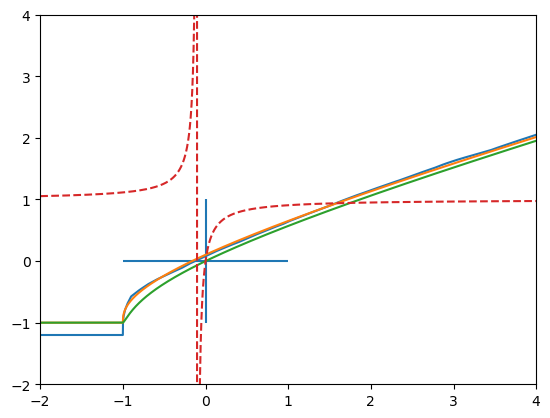

In [15]:
line = np.linspace(-2.0, 4.0, 10000)
i = 1

plt.vlines(0.0, -1.0, 1.0)
plt.hlines(0.0, -1.0, 1.0)

plt.plot(line, gs[i](line))

print(gans[i](0))
hyp_a = 1/(gans[i](0) + 1)
hyp_alpha = 1/hyp_a - 1

def hyp(t):
    return 1 - hyp_alpha / (hyp_alpha + t)

plt.plot(line, gans[i](line))
plt.plot(line, (gans[i](line) + 1) * hyp(line+1) - 1)
plt.plot(line, hyp(line), linestyle='dashed')


plt.xlim(-2.0, 4.0)
plt.ylim(-2.0, 4.0)


In [16]:
for i in range(len(surveys)):
    print(f"{surveys[i]} -- Average original: {np.average(ovds[i][masks[i]]):.3g}, corrected: {np.average(ovds_new[i][masks[i]]):.3g}")

2mass -- Average original: -5.81e-17, corrected: -3.6e-17
6df -- Average original: -2.48e-17, corrected: -5.83e-18
sdss -- Average original: -1.58e-17, corrected: -2.03e-17


0.9899317578521227


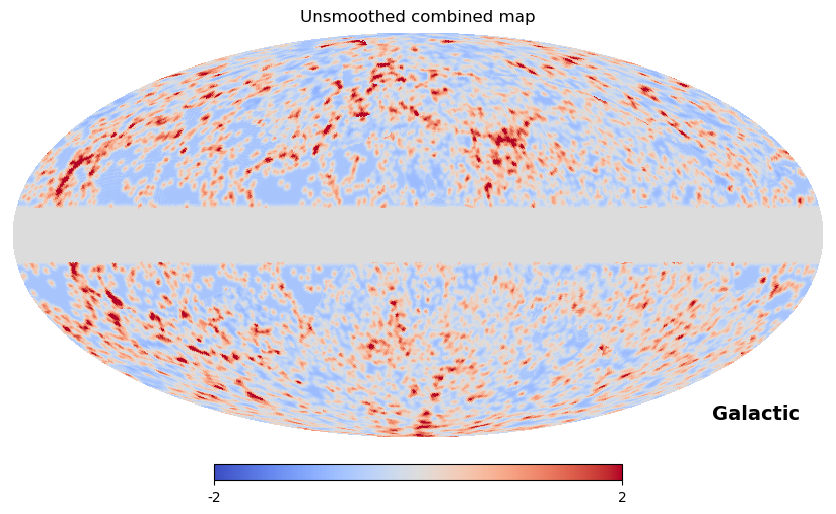

In [17]:
npix = hp.nside2npix(128)
free = np.zeros(npix)
tot_weights = np.zeros(npix)

for i in range(len(surveys)):
    free[masks[i]] += ovds_new[i][masks[i]] * avgs[i]
    tot_weights[masks[i]] += avgs[i]
        
free[mask_total] = free[mask_total] / tot_weights[mask_total]
empirical_mean = np.average(free[mask_total]) + 1
print(empirical_mean)

# put average to 0 again!!!
free[mask_total] = (free[mask_total] + 1) / empirical_mean - 1

hp.mollview(free,
            title="Unsmoothed combined map",
            coord=['C', 'G'],
            cmap='coolwarm',
            min=-2, max=2)

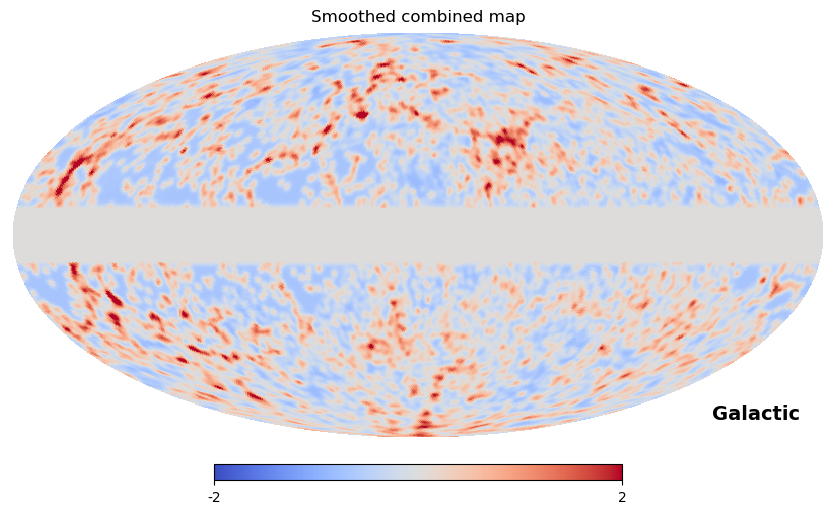

In [18]:
# now we smooth the second time
free_s = hp.smoothing(free, sigma=np.deg2rad(sm_deg)) * mask_total
empirical_mean = np.average(free_s[mask_total]) + 1

free_s[mask_total] = ((free_s[mask_total] + 1) / empirical_mean - 1) 
# print(np.average(free_s))

hp.mollview(free_s,
            title='Smoothed combined map',
            coord=['C', 'G'],
            cmap='coolwarm',
            min=-2, max=2)

## 4. Join for all the maps

In [19]:
ns = len(surveys)
nz = len(zbin_names)

In [20]:
map_example = data[0][0]

z_avg = np.average(np.array(zbins), axis=1)

sm_deg = np.zeros(len(zbin_names))
avgs = np.zeros((len(surveys), len(zbin_names)))
excess_s = np.zeros((len(surveys), len(zbin_names), hp.get_map_size(map_example)))

# smoothing size is a maximum between 5 Mpc scale and pixel size
smoothing_scale = 5 * u.Mpc
pix_size = np.rad2deg(hp.nside2resol(hp.get_nside(map_example)))
sm_deg = np.maximum((smoothing_scale / cosmo.kpc_comoving_per_arcmin(z_avg)).to_value(u.deg), pix_size)

for j in range(nz):
    for i in range(ns):
        # AVERAGE VALUE in the masked region
        avgs[i, j] = np.average(data[i][j][masks[i]])   
        
        # SMOOTHED DATA excess values to simplify the distribution correction procedure
        excess_s[i, j] = hp.smoothing(                     
            (data[i][j] - avgs[i, j]) * masks[i],       # data in the masked region is corrected by the average value
            sigma=np.deg2rad(sm_deg[j])
            ) * masks[i]                            # only data in the masked region is non-zero

# calculate overdensities as excess/average ratio
ovds = excess_s / avgs[:, :, None]

#### Test raw overdensity values

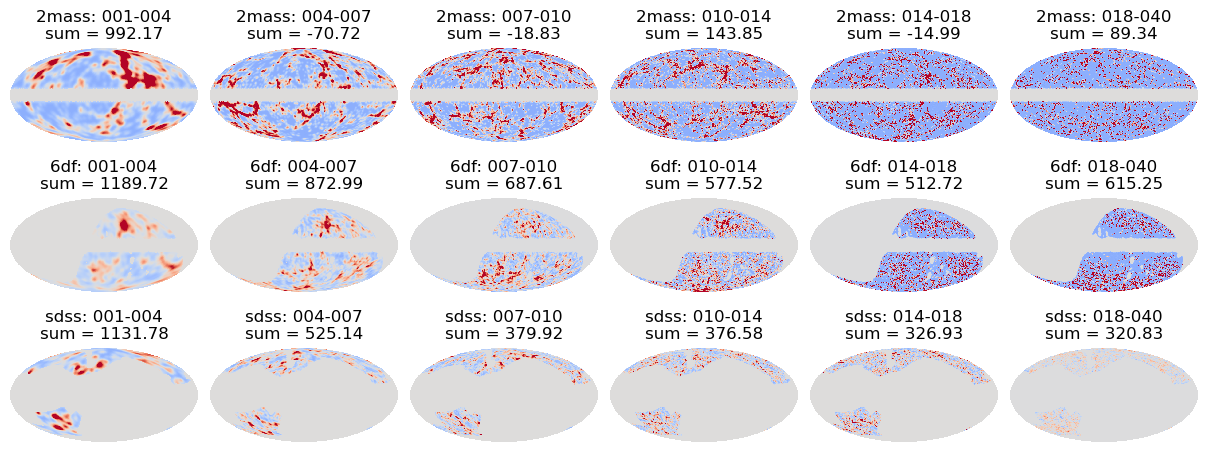

In [21]:
# Create one large figure to hold everything
fig = plt.figure(figsize=(12, 1.5 * ns))

for j in range(nz):
    for i in range(ns):
        hp.mollview(
            ovds[i, j], min=-2, max=2,
            sub=(ns, nz, 1 + j + i * nz),
            coord=['C', 'G'],
            notext=True,
            cmap='coolwarm',
            cbar=False,
            title=f"{surveys[i]}: {zbin_names[j]}\nsum = {np.sum(ovds[i, j][masks[i]]):.2f}",
            hold=False
        )   

plt.show()

### Define gamma distributions

In [22]:
# organize a list for gamma functions and for maps g(x)
gammas = np.zeros_like(avgs).tolist()

for j in range(nz):  
    for i in range(ns):
        ovds_ij = ovds[i,j][masks[i]] # overdensity in the masked region        

        # set gamma distribution
        alpha = 1/np.std(ovds_ij)**2
        gm = sps.gamma(loc=-1.0, a=alpha, scale=1/alpha)
        gammas[i][j] = gm

#### Check gamma distributions

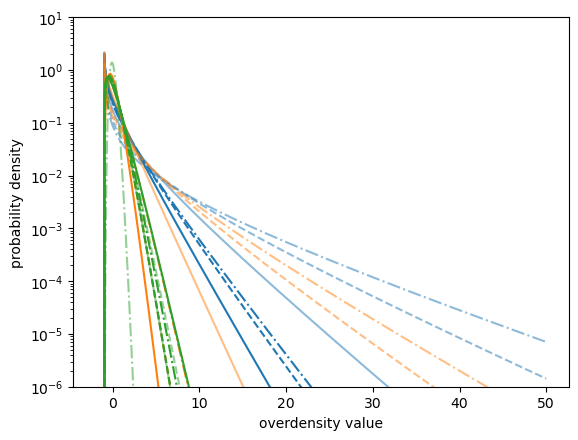

In [23]:
x1 = np.linspace(-2, 50, 1000)

for i in range(ns):
    for j in range(nz):
        plt.plot(x1, gammas[i][j].pdf(x1),
                 color=Tab10[i],
                 linestyle=['solid', 'dashed', 'dashdot'][j%3],
                 alpha=[1.0, 0.5][j//3])

plt.xlabel('overdensity value')

plt.yscale('log')
plt.ylim(1e-6, 10)
plt.ylabel('probability density')

plt.show()

### Map overdensities with the use of gamma functions

In [24]:
# prepare an array for mapped overdensity
ovds_new = np.zeros_like(ovds)
        
for j in range(len(zbin_names)):
    
    i_max = np.argmax(avgs[:, j])     # the richest data
    print(f"The richest data in the bin {zbin_names[j]} if in {surveys[i_max]}")
    avg_max = avgs[i_max, j]          # the density of the reachest data
    
    for i in range(len(surveys)):
        ovds_ij = ovds[i,j][masks[i]] # overdensity in the masked region
        
        # define a map as g(t) = F_Ym1(F_X(t))
        def g_an(t):
            F_Ym1 = gammas[i_max][j].ppf
            F_X = gammas[i][j].cdf
            return F_Ym1(F_X(t))
        
        # map old distribution to a new one
        ovds_new[i,j] = g_an(ovds[i,j])

The richest data in the bin 001-004 if in 6df
The richest data in the bin 004-007 if in 6df
The richest data in the bin 007-010 if in sdss
The richest data in the bin 010-014 if in sdss
The richest data in the bin 014-018 if in sdss
The richest data in the bin 018-040 if in sdss


#### Check mapped overdensities

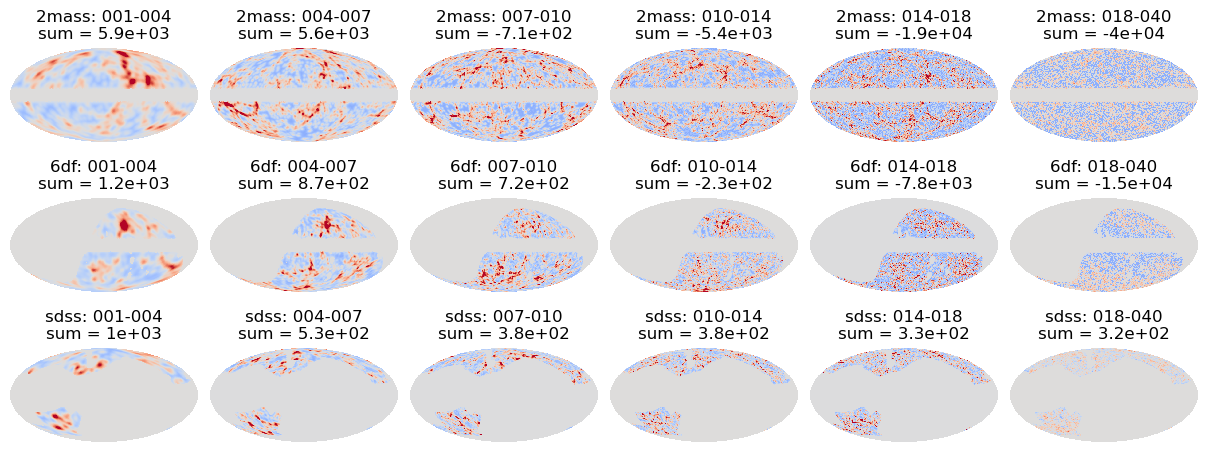

In [25]:
fig = plt.figure(figsize=(12, 1.5 * ns))

for j in range(nz):
    for i in range(ns):
        hp.mollview(
            ovds_new[i, j] * masks[i],
            min=-2, max=2,
            sub=(ns, nz, 1 + j + i * nz),
            coord=['C', 'G'],
            notext=True,
            cbar=False,
            cmap='coolwarm',
            title=f"{surveys[i]}: {zbin_names[j]}\nsum = {np.sum(ovds_new[i, j] * masks[i]):.2g}",
            hold=False
        )   

plt.show()

### Sum the maps

In [26]:
# and finaly we sum the maps
free = np.zeros((len(zbin_names), hp.get_map_size(map_example)))
tot_weights, final, final_s = np.zeros_like(free), np.zeros_like(free), np.zeros_like(free)
    
for j in range(len(zbin_names)):
    for i in range(len(surveys)):
        # add up maps with their weights
        free[j] += ovds_new[i,j] * masks[i] * avgs[i,j]
        # calculate weights for each survey
        tot_weights[j] += masks[i] * avgs[i,j]
    
    good = tot_weights[j] > 0
    final[j, good] = (free[j, good] / tot_weights[j, good])
    
    # and smooth each final map
    final_s[j] = hp.smoothing(
        final[j] * mask_total,
        sigma=np.deg2rad(sm_deg[j])
    ) * mask_total

#### Check the weights and overdfensity maps

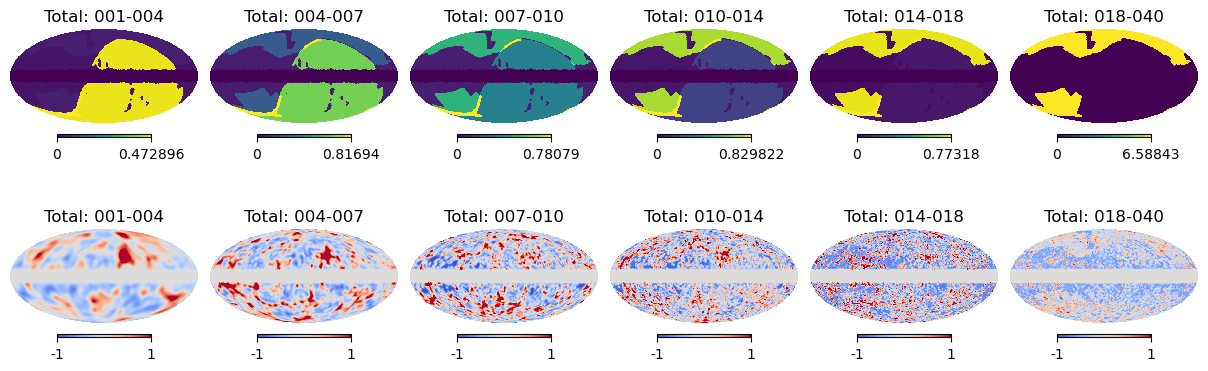

In [27]:
fig = plt.figure(figsize=(12, 4))

for j in range(nz):
    hp.mollview(
        tot_weights[j], min=0, max=max(tot_weights[j]),
        sub=(2, nz, 1 + j),
        coord=['C', 'G'],
        notext=True,
        title=f"Total: {zbin_names[j]}",
        hold=False
    )
    
    hp.mollview(
        final_s[j], min=-1, max=1,
        sub=(2, nz, 1 + j + nz),
        coord=['C', 'G'],
        notext=True,
        cmap='coolwarm',
        title=f"Total: {zbin_names[j]}",
        hold=False
    )  

plt.show()

### Construct the final map

#### Import clusters

In [28]:
# CLUSTERS
import pandas as pd
from astropy.coordinates import SkyCoord
clusters = pd.read_csv("./galcats/clusters.csv")
clusters_coords = SkyCoord(clusters["RA"], clusters["Dec"], frame='icrs').galactic

#### Produce the map

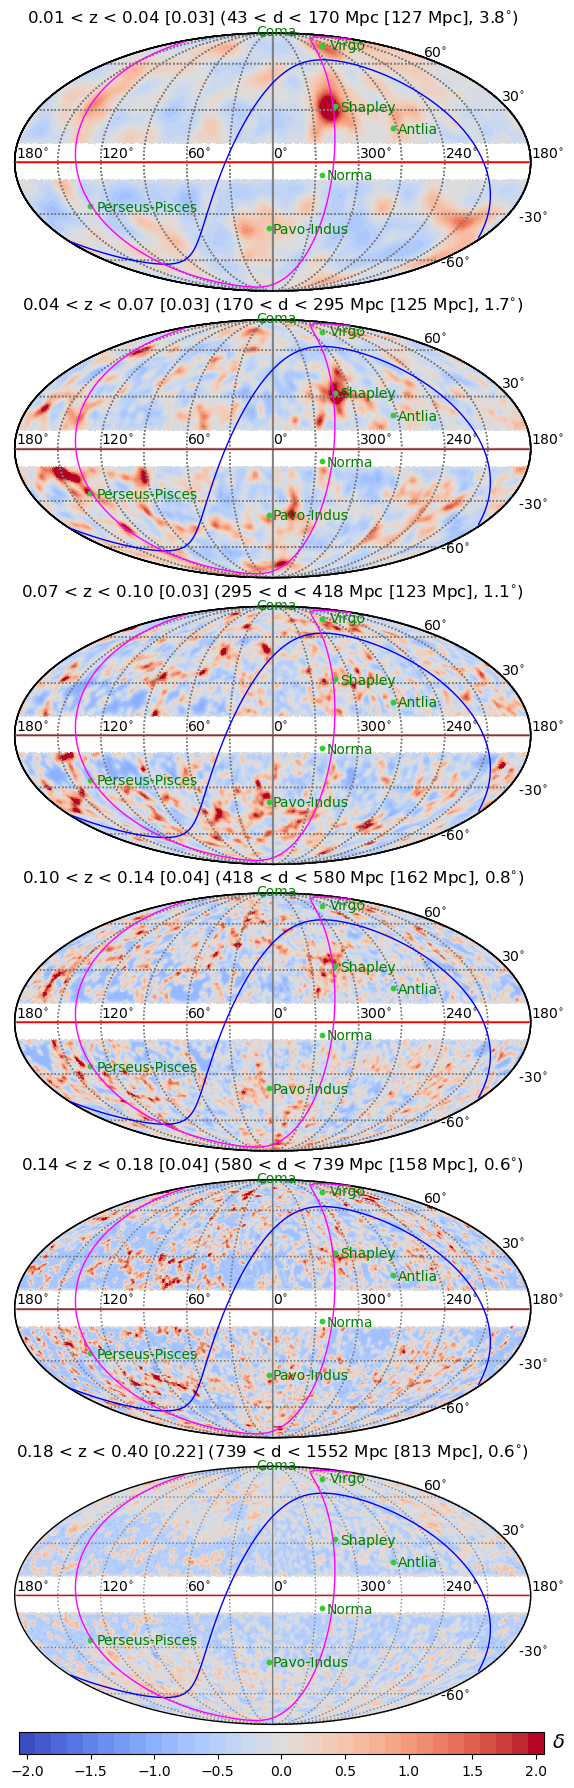

In [64]:
from matplotlib.axes import Axes
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from scipy.stats import norm

# 1. Create a figure and define a grid
fig = plt.figure(figsize=(7, 22))

# GridSpec: n_bins rows, 6 columns 
# (4 columns for maps, 1 for histograms, 1 for a bit of padding/colorbar space)
# Add one extra row for the colorbar
gs = gridspec.GridSpec(6, 1, hspace=0.1)

cmap_norm = plt.Normalize(vmin=-2.0625, vmax=2.0625)
cmap = plt.get_cmap('coolwarm', lut=33)

maps_final = []

for j in range(len(zbin_names)):
    # 2. Plot the Map (occupies columns 0 to 3)
    # The 'sub' parameter takes (nrows, ncols, plot_number)
    ax = fig.add_subplot(gs[j, 0]) # Create the axis where you want it
    plt.sca(ax)                     # Set Current Axis to the one we just made
    
    to_show = np.copy(final_s[j])
    to_show[~mask_total] = hp.UNSEEN
    
    hp.mollview(
        to_show, 
        min=-2.0625, max=2.0625, 
        coord=['C', 'G'],
        cmap=cmap,
        badcolor='white',
        cbar=False,
        title=f"{zbins[j][0]:.2f} < z < {zbins[j][1]:.2f} [{zbins[j][1] - zbins[j][0]:.2f}] "
              f"({bins_d[j][0]:.0f} < d < {bins_d[j][1]:.0f} Mpc [{bins_d[j][1] - bins_d[j][0]:.0f} Mpc], {np.sqrt(2) * sm_deg[j]:.1f}"r"$\!{}^\circ\!$)",
        sub=None,
        notext=True,
        hold=True
    )
    hp.graticule(color='gray')

hp.projplot(theta_MW, phi_MW, color='red', coord='G', linewidth=1.0)
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='G', linewidth=1.0)
hp.projplot(theta_SG, phi_SG, color='magenta', coord='G', linewidth=1.0)

hp.projscatter(np.pi/2 - clusters_coords.b.rad, clusters_coords.l.rad, coord='G',
               marker='o', s=10, color='limegreen')
for k in range(clusters["Name"].size):
    hp.projtext(np.pi/2 - clusters_coords.b.rad[k] + 0.05, clusters_coords.l.rad[k] - 0.05,
                f"{clusters['Name'][k]}", coord='G', color='green')
    
for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180), f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")
    
# 3. Add the Single Global Colorbar
cbar_ax: Axes = fig.add_axes([0.15, 0.097, 0.75, 0.01]) 
cb = fig.colorbar(cm.ScalarMappable(norm=cmap_norm, cmap=cmap),
                  cax=cbar_ax, orientation='horizontal', aspect=40)
cbar_ax.set_ylabel(r'$\delta$', rotation=0, loc='top', labelpad=15, fontsize=14)
cbar_ax.yaxis.set_label_position('right')

plt.savefig("./figures/lss-final-v.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

In [32]:
## save overdensity maps
for j in range(nz):
    np.save(f"./overdensity/maps{zbin_names[j]}", final_s[j])